In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [11]:
df = pd.read_csv('RawData.csv')
df = df.rename(columns={"Unnamed: 0": "ID"})

USER_ID_COL = "ID"
TARGET_USER = 1

METRICS = [
    "SLEEP_HOURS",
    "PHYSICAL_ACTIVITY_HOURS_PER_DAY",
    "DIET_CALORIES",
    "HEALTH_RISK_SCORE",
    "LIFESTYLE_SCORE"
]

df = df[[USER_ID_COL] + METRICS].dropna()
df.head()

,ID,SLEEP_HOURS,PHYSICAL_ACTIVITY_HOURS_PER_DAY,DIET_CALORIES,HEALTH_RISK_SCORE,LIFESTYLE_SCORE
0,0,6.1,4.0,3125,19.2863,7.8509
1,1,6.8,2.3,3462,23.9758,6.7363
2,2,7.9,5.9,2021,36.6935,9.2592
3,3,5.0,5.4,3992,26.5986,3.4177
4,4,8.9,3.9,2463,39.1394,2.9095


In [12]:
df_user_level = df.copy()

In [13]:
def percentile_against_others(values, user_value):
    others = values.dropna()
    pct = (others < user_value).mean() * 100
    return round(pct, 1)

def comparison_text(metric_name, user_value, percentile):
    if percentile == 50:
        return f"Your {metric_name} is about average."
    if percentile > 50:
        return f"Your {metric_name} is higher than {percentile:.0f}% of people."
    return f"Your {metric_name} is lower than {100 - percentile:.0f}% of people."

user_row = df_user_level[df_user_level[USER_ID_COL] == TARGET_USER]
if user_row.empty:
    raise ValueError(f"User {TARGET_USER} not found.")

user_row = user_row.iloc[0]

summary = []
for metric in METRICS:
    user_value = user_row[metric]
    peer_values = df_user_level.loc[df_user_level[USER_ID_COL] != TARGET_USER, metric]
    pct = percentile_against_others(peer_values, user_value)
    summary.append({
        "metric": metric,
        "user_value": user_value,
        "percentile": pct,
        "message": comparison_text(metric.replace("_", " "), user_value, pct)
    })

summary_df = pd.DataFrame(summary)
summary_df

,metric,user_value,percentile,message
0,SLEEP_HOURS,6.8000,43.7,Your SLEEP HOURS is lower than 56% of people.
1,PHYSICAL_ACTIVITY_HOURS_PER_DAY,2.3000,11.2,Your PHYSICAL ACTIVITY HOURS PER DAY is lower ...
2,DIET_CALORIES,3462.0000,89.6,Your DIET CALORIES is higher than 90% of people.
3,HEALTH_RISK_SCORE,23.9758,37.1,Your HEALTH RISK SCORE is lower than 63% of pe...
4,LIFESTYLE_SCORE,6.7363,52.9,Your LIFESTYLE SCORE is higher than 53% of peo...


In [14]:
for msg in summary_df["message"]:
    print("•", msg)

• Your SLEEP HOURS is lower than 56% of people.
• Your PHYSICAL ACTIVITY HOURS PER DAY is lower than 89% of people.
• Your DIET CALORIES is higher than 90% of people.
• Your HEALTH RISK SCORE is lower than 63% of people.
• Your LIFESTYLE SCORE is higher than 53% of people.


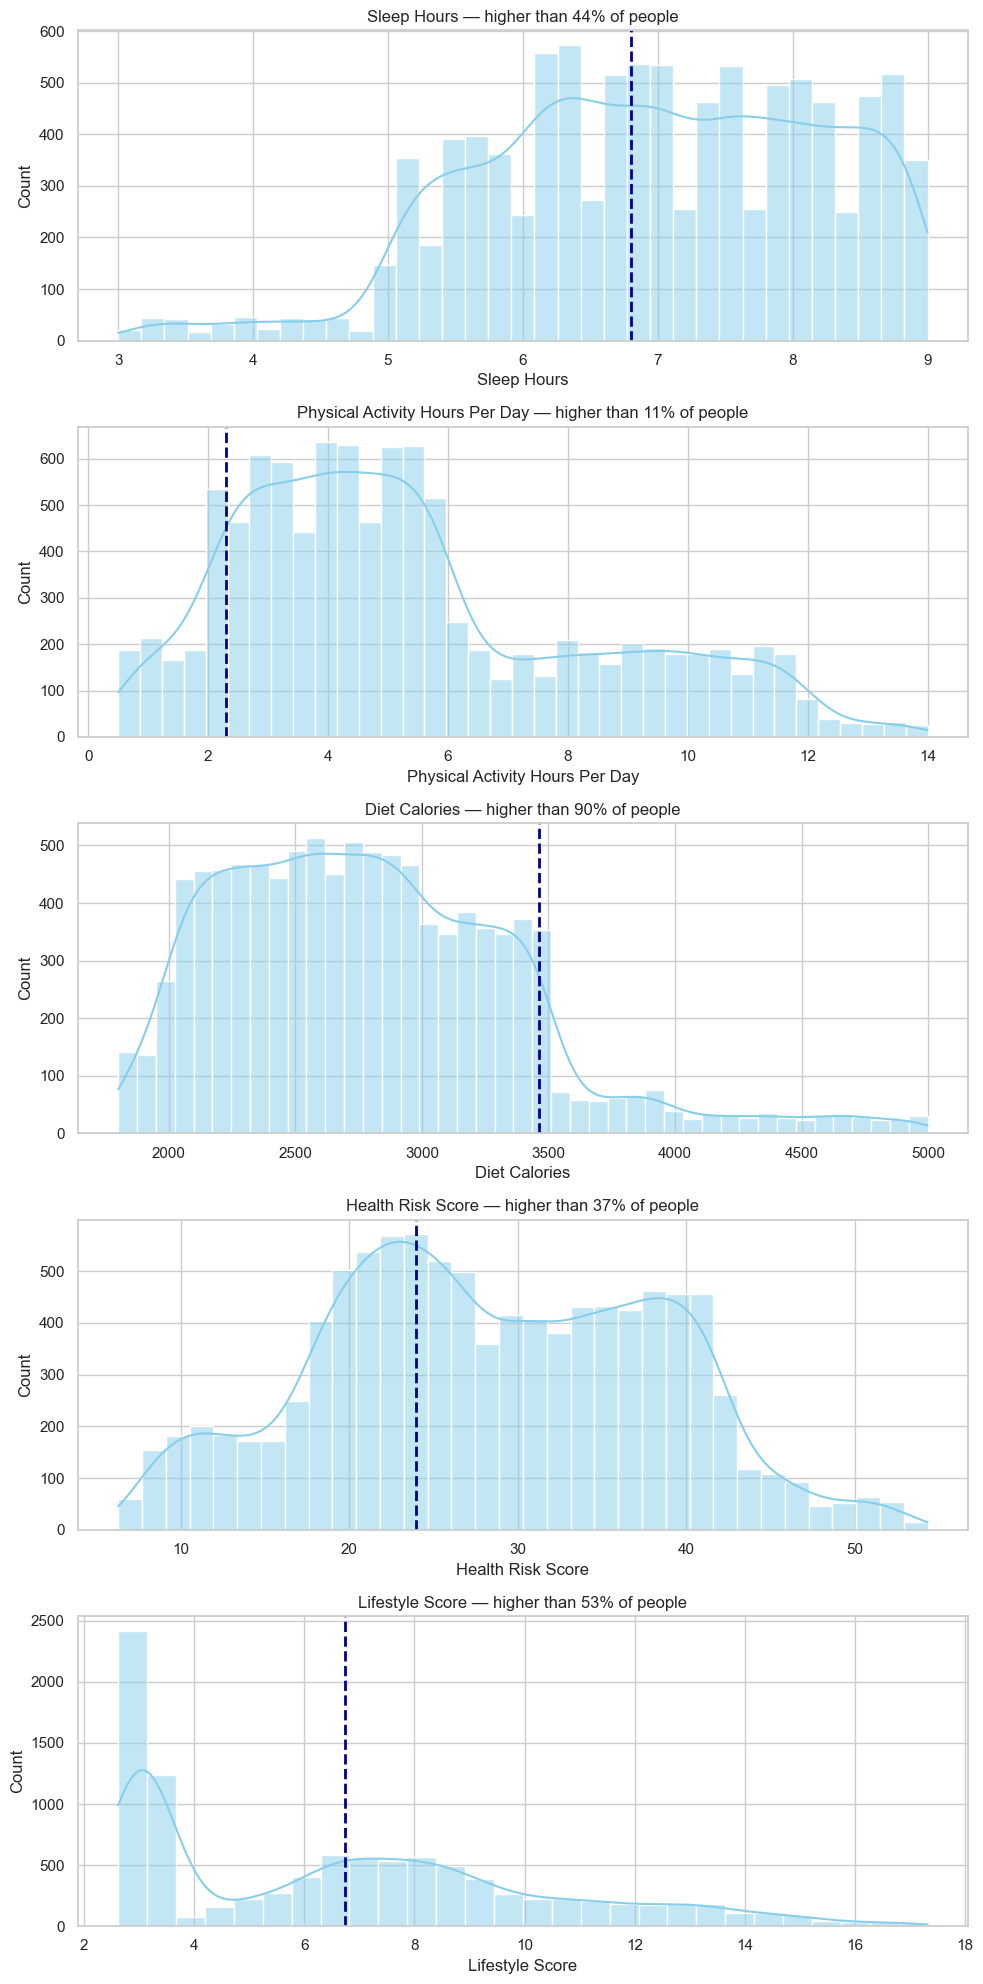

In [16]:
n = len(METRICS)
fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))

if n == 1:
    axes = [axes]

for ax, metric in zip(axes, METRICS):
    peer_values = df_user_level.loc[df_user_level[USER_ID_COL] != TARGET_USER, metric]
    user_value = user_row[metric]
    pct = summary_df.loc[summary_df["metric"] == metric, "percentile"].iloc[0]

    sns.histplot(peer_values, kde=True, ax=ax, color="skyblue")
    ax.axvline(user_value, color="darkblue", linestyle="--", linewidth=2)
    ax.set_title(f"{metric.replace('_', ' ').title()} — higher than {pct:.0f}% of people")
    ax.set_xlabel(metric.replace("_", " ").title())

plt.tight_layout()
plt.show()